# Trust Analysis: v1 (Buggy Memory) vs v2 (Fixed Memory)

Comparative trust analysis between two 3-game Diplomacy experiments:
- **v1** (`results/3game_experiment/`): Bug where memory was power-keyed (models never got their own memory)
- **v2** (`results/3game_experiment_v2/`): Fixed — memory is model-keyed

Both experiments use the same 7 models via OpenRouter with power rotation across games.

Key question: Does correct cross-game memory cause models to develop different trust patterns in games 2-3?

## 1. Data Loading

In [1]:
import os
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Base paths (relative from this notebook's directory)
BASE_DIR = os.path.join("..", "results")
V1_DIR = os.path.join(BASE_DIR, "3game_experiment")
V2_DIR = os.path.join(BASE_DIR, "3game_experiment_v2")

In [2]:
def load_experiment_summary(exp_dir):
    """Load experiment_summary.json and return power_model_map per game."""
    summary_path = os.path.join(exp_dir, "experiment_summary.json")
    with open(summary_path) as f:
        data = json.load(f)
    return data

def strip_model_prefix(model_name):
    """Remove 'openrouter:' prefix from model names."""
    if model_name.startswith("openrouter:"):
        return model_name[len("openrouter:"):]
    return model_name

def extract_trust_scores(raw_response):
    """Extract trust_scores dict from raw LLM response.
    
    Trust scores are embedded in JSON blocks, often wrapped in ```json...``` code fences.
    Returns dict like {"ENGLAND": 7, "FRANCE": 5, ...} or None.
    """
    if 'trust_scores' not in str(raw_response):
        return None
    
    # Try to find JSON in code fences first
    patterns = [
        r'```json\s*(\{.*?\})\s*```',  # ```json { ... } ```
        r'```\s*(\{.*?\})\s*```',       # ``` { ... } ```
        r'(\{[^{}]*"trust_scores"[^{}]*\{[^}]*\}[^}]*\})',  # bare JSON with trust_scores
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, str(raw_response), re.DOTALL)
        for match in matches:
            if 'trust_scores' in match:
                try:
                    data = json.loads(match)
                    if 'trust_scores' in data:
                        return data['trust_scores']
                except json.JSONDecodeError:
                    continue
    
    # Fallback: try to find trust_scores key in a larger JSON blob
    try:
        # Find the outermost JSON object containing trust_scores
        start = str(raw_response).find('{"')
        if start == -1:
            start = str(raw_response).find('{\n')
        if start >= 0:
            # Try progressively larger substrings
            text = str(raw_response)[start:]
            depth = 0
            for i, c in enumerate(text):
                if c == '{':
                    depth += 1
                elif c == '}':
                    depth -= 1
                    if depth == 0:
                        try:
                            data = json.loads(text[:i+1])
                            if 'trust_scores' in data:
                                return data['trust_scores']
                        except json.JSONDecodeError:
                            pass
                        break
    except Exception:
        pass
    
    return None

def extract_year_from_phase(phase):
    """Extract year number from phase string like 'S1901M', 'F1905R', etc."""
    match = re.search(r'(\d{4})', str(phase))
    if match:
        return int(match.group(1))
    return None

print("Utility functions defined.")

Utility functions defined.


In [3]:
def load_trust_data(exp_dir, experiment_name):
    """Load all trust scores from an experiment's games.
    
    Returns a list of dicts with:
    experiment, game, phase, year, evaluating_power, target_power, score, model
    """
    summary = load_experiment_summary(exp_dir)
    records = []
    
    for game_num in range(1, 4):
        game_key = f"game{game_num}"
        csv_path = os.path.join(exp_dir, game_key, "llm_responses.csv")
        
        if not os.path.exists(csv_path):
            print(f"  WARNING: {csv_path} not found, skipping.")
            continue
        
        # Get power-model map for this game
        power_model_map = summary['results'][game_key]['power_model_map']
        
        # Load CSV
        df = pd.read_csv(csv_path)
        
        # Filter for successful responses only
        df = df[df['success'] != False]
        df = df[df['success'].astype(str).str.upper() != 'FALSE']
        
        # Process each row
        trust_count = 0
        for _, row in df.iterrows():
            trust_scores = extract_trust_scores(row.get('raw_response', ''))
            if trust_scores is None:
                continue
            
            evaluating_power = row['power']
            phase = row['phase']
            year = extract_year_from_phase(phase)
            model = strip_model_prefix(power_model_map.get(evaluating_power, row.get('model', 'unknown')))
            
            for target_power, score in trust_scores.items():
                target_power_upper = target_power.upper()
                try:
                    score_val = float(score)
                except (ValueError, TypeError):
                    continue
                
                records.append({
                    'experiment': experiment_name,
                    'game': game_num,
                    'phase': phase,
                    'year': year,
                    'evaluating_power': evaluating_power,
                    'target_power': target_power_upper,
                    'score': score_val,
                    'model': model,
                })
                trust_count += 1
        
        print(f"  {experiment_name} game{game_num}: {trust_count} trust score entries")
    
    return records

# Load data from both experiments
print("Loading v1 (buggy memory)...")
v1_records = load_trust_data(V1_DIR, 'v1')

print("\nLoading v2 (fixed memory)...")
v2_records = load_trust_data(V2_DIR, 'v2')

# Combine into single DataFrame
trust_df = pd.DataFrame(v1_records + v2_records)
print(f"\nTotal trust DataFrame: {len(trust_df)} rows")
print(f"  v1: {len(trust_df[trust_df['experiment'] == 'v1'])} rows")
print(f"  v2: {len(trust_df[trust_df['experiment'] == 'v2'])} rows")
print(f"\nModels: {sorted(trust_df['model'].unique())}")
trust_df.head(10)

Loading v1 (buggy memory)...
  v1 game1: 870 trust score entries


  v1 game2: 809 trust score entries


  v1 game3: 752 trust score entries

Loading v2 (fixed memory)...
  v2 game1: 746 trust score entries


  v2 game2: 789 trust score entries


  v2 game3: 729 trust score entries

Total trust DataFrame: 4695 rows
  v1: 2431 rows
  v2: 2264 rows

Models: ['anthropic/claude-haiku-4.5', 'google/gemini-2.5-flash-lite', 'google/gemma-4-31b-it', 'openai/gpt-oss-120b', 'qwen/qwen3.5-27b', 'qwen/qwen3.6-plus', 'x-ai/grok-4.1-fast']


,experiment,game,phase,year,evaluating_power,target_power,score,model
0,v1,1,S1901M,1901,FRANCE,AUSTRIA,0.50,google/gemini-2.5-flash-lite
1,v1,1,S1901M,1901,FRANCE,ITALY,0.80,google/gemini-2.5-flash-lite
2,v1,1,S1901M,1901,FRANCE,ENGLAND,0.20,google/gemini-2.5-flash-lite
3,v1,1,S1901M,1901,FRANCE,TURKEY,0.50,google/gemini-2.5-flash-lite
4,v1,1,S1901M,1901,FRANCE,GERMANY,0.70,google/gemini-2.5-flash-lite
5,v1,1,S1901M,1901,FRANCE,RUSSIA,0.50,google/gemini-2.5-flash-lite
6,v1,1,S1901M,1901,TURKEY,AUSTRIA,0.75,anthropic/claude-haiku-4.5
7,v1,1,S1901M,1901,TURKEY,ITALY,0.75,anthropic/claude-haiku-4.5
8,v1,1,S1901M,1901,TURKEY,RUSSIA,0.55,anthropic/claude-haiku-4.5
9,v1,1,S1901M,1901,TURKEY,FRANCE,0.50,anthropic/claude-haiku-4.5


## 2. Average Baseline Trust by Model (v1 vs v2)

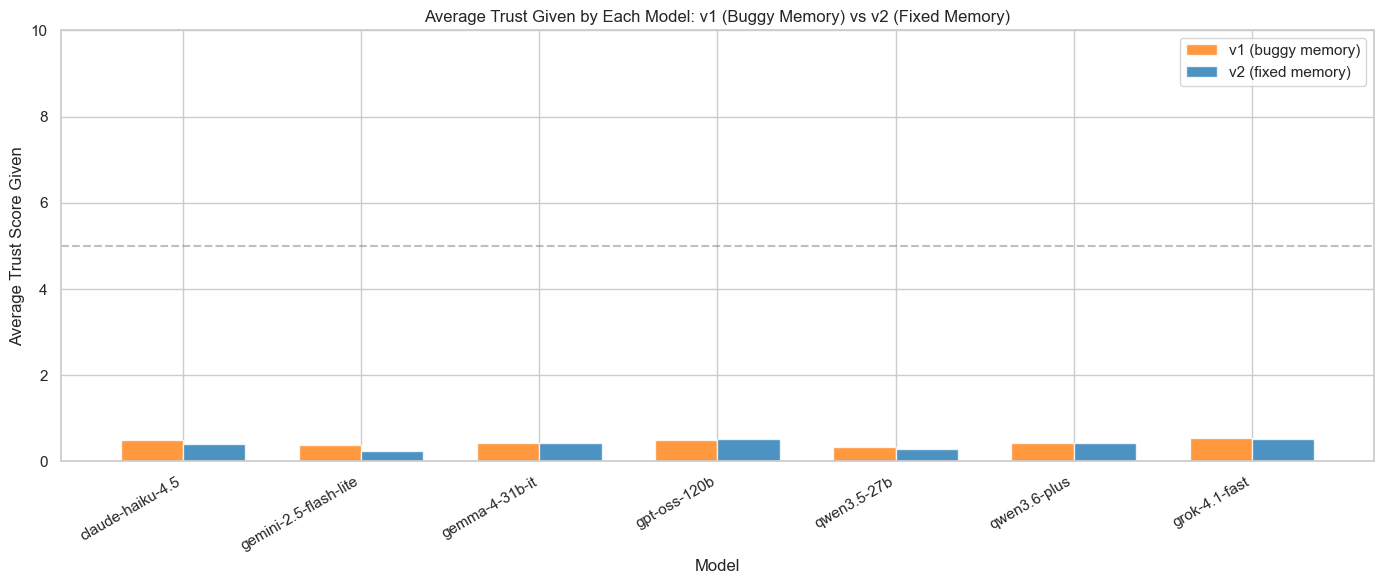


Average Trust Given (higher = more trusting):


experiment,v1,v2,delta
model,,,
openai/gpt-oss-120b,0.51,0.52,0.01
qwen/qwen3.6-plus,0.42,0.43,0.01
google/gemma-4-31b-it,0.43,0.43,0.00
x-ai/grok-4.1-fast,0.54,0.53,-0.01
qwen/qwen3.5-27b,0.33,0.28,-0.05
anthropic/claude-haiku-4.5,0.49,0.41,-0.08
google/gemini-2.5-flash-lite,0.39,0.25,-0.14


In [4]:
# Average trust GIVEN by each model, comparing v1 vs v2
avg_trust_given = trust_df.groupby(['model', 'experiment'])['score'].mean().reset_index()
avg_trust_given = avg_trust_given.sort_values('model')

fig, ax = plt.subplots(figsize=(14, 6))
models = sorted(avg_trust_given['model'].unique())
x = np.arange(len(models))
width = 0.35

v1_means = [avg_trust_given[(avg_trust_given['model'] == m) & (avg_trust_given['experiment'] == 'v1')]['score'].values
            for m in models]
v1_means = [v[0] if len(v) > 0 else 0 for v in v1_means]

v2_means = [avg_trust_given[(avg_trust_given['model'] == m) & (avg_trust_given['experiment'] == 'v2')]['score'].values
            for m in models]
v2_means = [v[0] if len(v) > 0 else 0 for v in v2_means]

bars1 = ax.bar(x - width/2, v1_means, width, label='v1 (buggy memory)', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, v2_means, width, label='v2 (fixed memory)', color='#1f77b4', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Average Trust Score Given')
ax.set_title('Average Trust Given by Each Model: v1 (Buggy Memory) vs v2 (Fixed Memory)')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in models], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='Neutral (5)')

plt.tight_layout()
plt.show()

# Print summary table
pivot = avg_trust_given.pivot(index='model', columns='experiment', values='score')
pivot['delta'] = pivot['v2'] - pivot['v1']
pivot = pivot.round(2)
print("\nAverage Trust Given (higher = more trusting):")
display(pivot.sort_values('delta', ascending=False))

## 3. Trust Progression Over Time

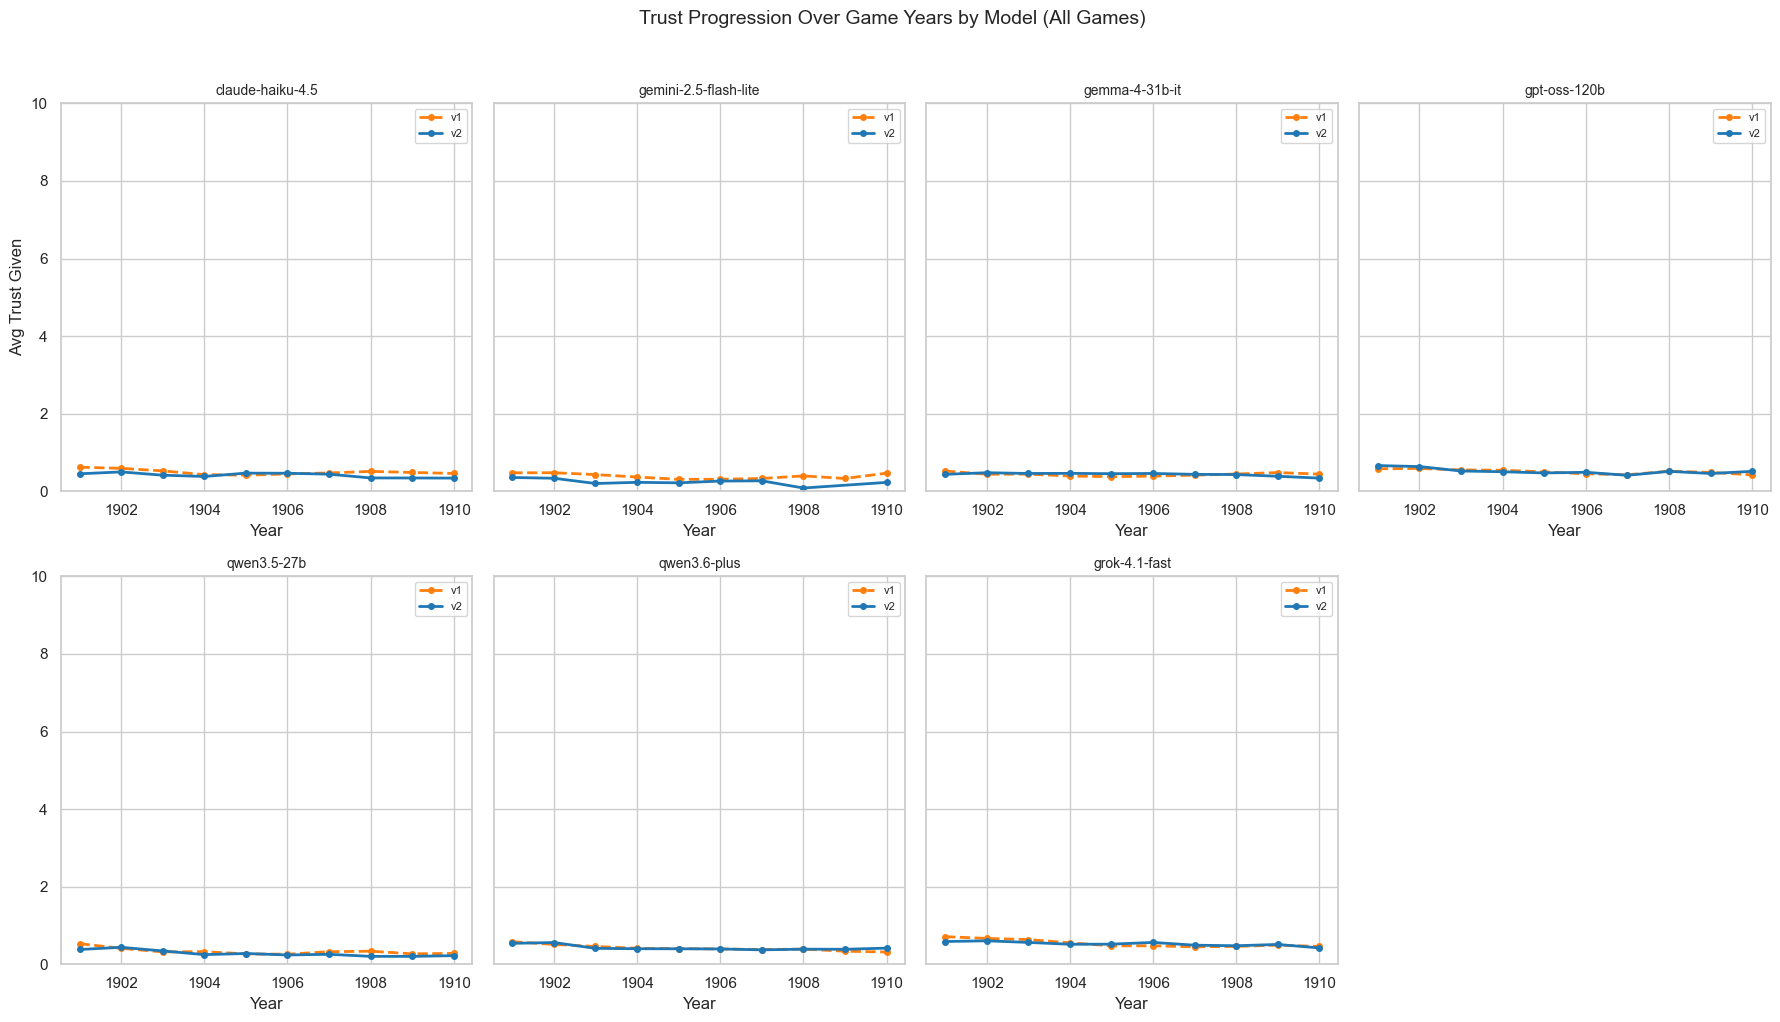

In [5]:
# Average trust given per model over game years, colored by experiment
yearly_trust = trust_df.groupby(['model', 'experiment', 'year'])['score'].mean().reset_index()

models = sorted(trust_df['model'].unique())
n_models = len(models)
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, model in enumerate(models):
    ax = axes[i]
    model_data = yearly_trust[yearly_trust['model'] == model]
    
    for exp, color, ls in [('v1', '#ff7f0e', '--'), ('v2', '#1f77b4', '-')]:
        exp_data = model_data[model_data['experiment'] == exp].sort_values('year')
        if not exp_data.empty:
            ax.plot(exp_data['year'], exp_data['score'], color=color, linestyle=ls,
                    marker='o', markersize=4, label=exp, linewidth=2)
    
    ax.set_title(model.split('/')[-1], fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Avg Trust Given')
    ax.legend(fontsize=8)

# Hide extra subplot
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Trust Progression Over Game Years by Model (All Games)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

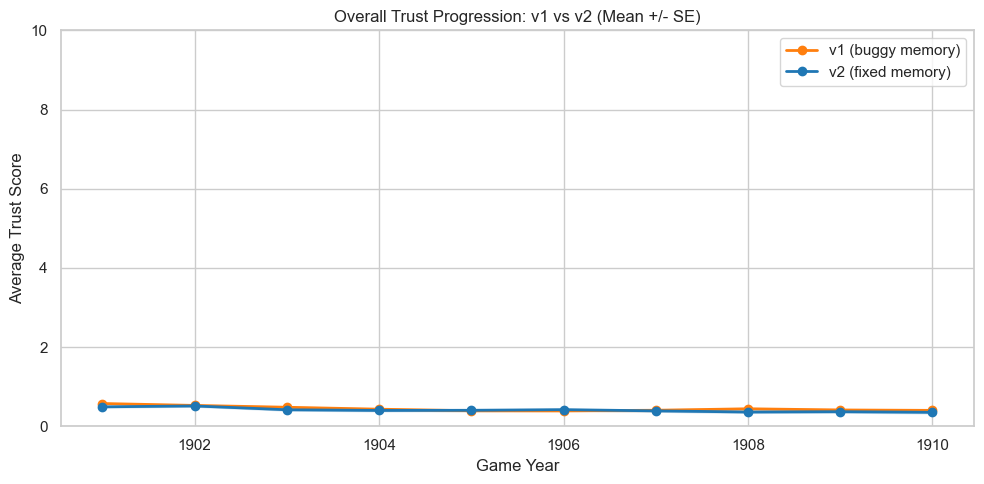

In [6]:
# Aggregate view: average across all models
agg_yearly = trust_df.groupby(['experiment', 'year'])['score'].agg(['mean', 'std', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for exp, color, label in [('v1', '#ff7f0e', 'v1 (buggy memory)'), ('v2', '#1f77b4', 'v2 (fixed memory)')]:
    data = agg_yearly[agg_yearly['experiment'] == exp].sort_values('year')
    ax.plot(data['year'], data['mean'], color=color, marker='o', label=label, linewidth=2)
    ax.fill_between(data['year'],
                    data['mean'] - data['std']/np.sqrt(data['count']),
                    data['mean'] + data['std']/np.sqrt(data['count']),
                    color=color, alpha=0.2)

ax.set_xlabel('Game Year')
ax.set_ylabel('Average Trust Score')
ax.set_title('Overall Trust Progression: v1 vs v2 (Mean +/- SE)')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Trust in Games 2-3 Only (Where Memory Matters)

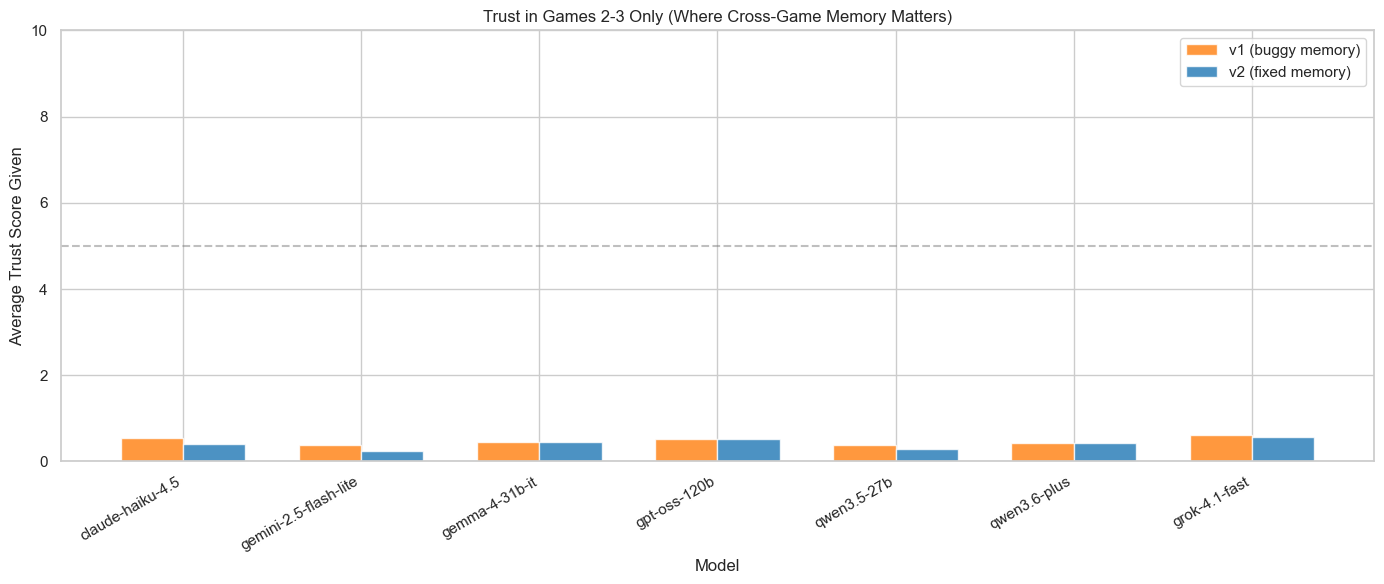


Trust evolution from Game 1 to Games 2-3 (memory effect):
  claude-haiku-4.5          (v1): G1=0.42 -> G2-3=0.53 (+0.12)
  claude-haiku-4.5          (v2): G1=0.45 -> G2-3=0.40 (-0.05)
  gemini-2.5-flash-lite     (v1): G1=0.42 -> G2-3=0.37 (-0.04)
  gemini-2.5-flash-lite     (v2): G1=0.27 -> G2-3=0.23 (-0.03)
  gemma-4-31b-it            (v1): G1=0.40 -> G2-3=0.45 (+0.05)
  gemma-4-31b-it            (v2): G1=0.41 -> G2-3=0.44 (+0.03)
  gpt-oss-120b              (v1): G1=0.49 -> G2-3=0.52 (+0.02)
  gpt-oss-120b              (v2): G1=0.53 -> G2-3=0.51 (-0.02)
  qwen3.5-27b               (v1): G1=0.23 -> G2-3=0.38 (+0.15)
  qwen3.5-27b               (v2): G1=0.26 -> G2-3=0.30 (+0.04)
  qwen3.6-plus              (v1): G1=0.41 -> G2-3=0.42 (+0.01)
  qwen3.6-plus              (v2): G1=0.42 -> G2-3=0.43 (+0.01)
  grok-4.1-fast             (v1): G1=0.38 -> G2-3=0.62 (+0.24)
  grok-4.1-fast             (v2): G1=0.41 -> G2-3=0.56 (+0.15)


In [7]:
# Filter to games 2 and 3 only (where cross-game memory should influence behavior)
games23 = trust_df[trust_df['game'].isin([2, 3])]

avg_trust_g23 = games23.groupby(['model', 'experiment'])['score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
models = sorted(avg_trust_g23['model'].unique())
x = np.arange(len(models))
width = 0.35

v1_means = [avg_trust_g23[(avg_trust_g23['model'] == m) & (avg_trust_g23['experiment'] == 'v1')]['score'].values
            for m in models]
v1_means = [v[0] if len(v) > 0 else 0 for v in v1_means]

v2_means = [avg_trust_g23[(avg_trust_g23['model'] == m) & (avg_trust_g23['experiment'] == 'v2')]['score'].values
            for m in models]
v2_means = [v[0] if len(v) > 0 else 0 for v in v2_means]

bars1 = ax.bar(x - width/2, v1_means, width, label='v1 (buggy memory)', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, v2_means, width, label='v2 (fixed memory)', color='#1f77b4', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Average Trust Score Given')
ax.set_title('Trust in Games 2-3 Only (Where Cross-Game Memory Matters)')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in models], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Compare game1 vs games 2-3 to see memory effect
game1 = trust_df[trust_df['game'] == 1]

print("\nTrust evolution from Game 1 to Games 2-3 (memory effect):")
print("="*70)
for model in sorted(trust_df['model'].unique()):
    for exp in ['v1', 'v2']:
        g1_mean = game1[(game1['model'] == model) & (game1['experiment'] == exp)]['score'].mean()
        g23_mean = games23[(games23['model'] == model) & (games23['experiment'] == exp)]['score'].mean()
        if not np.isnan(g1_mean) and not np.isnan(g23_mean):
            delta = g23_mean - g1_mean
            direction = "+" if delta > 0 else ""
            print(f"  {model.split('/')[-1]:25s} ({exp}): G1={g1_mean:.2f} -> G2-3={g23_mean:.2f} ({direction}{delta:.2f})")

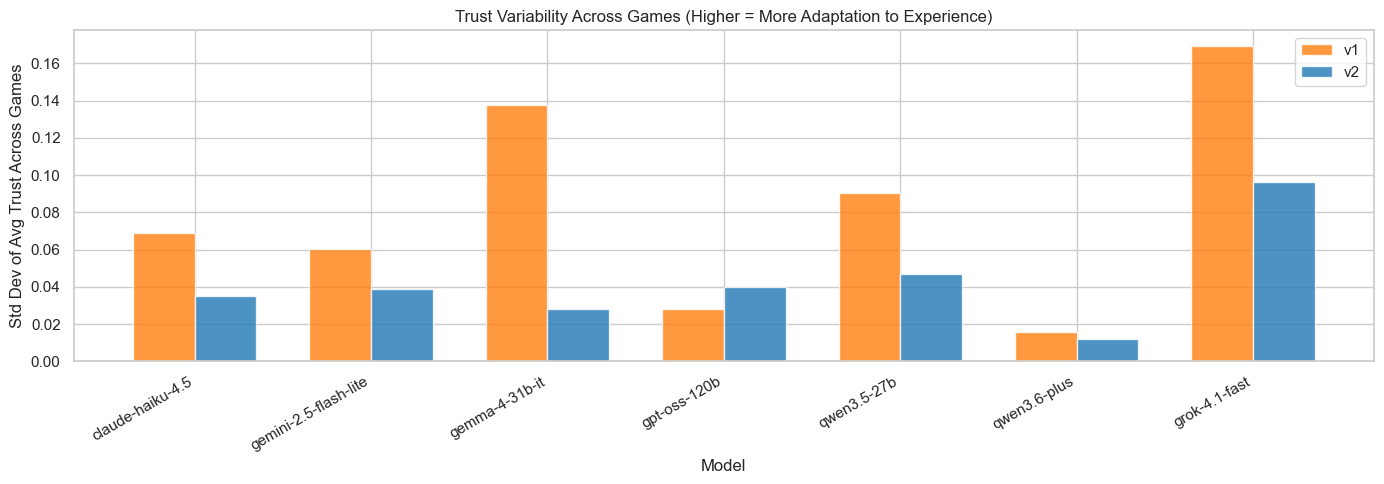

In [8]:
# Variance in trust across games — higher variance in v2 suggests memory is creating differentiated responses
trust_var = trust_df.groupby(['model', 'experiment', 'game'])['score'].mean().reset_index()
trust_var_agg = trust_var.groupby(['model', 'experiment'])['score'].std().reset_index()
trust_var_agg.columns = ['model', 'experiment', 'score_std_across_games']

fig, ax = plt.subplots(figsize=(14, 5))
pivot_var = trust_var_agg.pivot(index='model', columns='experiment', values='score_std_across_games').fillna(0)

x = np.arange(len(pivot_var))
width = 0.35
ax.bar(x - width/2, pivot_var.get('v1', [0]*len(pivot_var)), width, label='v1', color='#ff7f0e', alpha=0.8)
ax.bar(x + width/2, pivot_var.get('v2', [0]*len(pivot_var)), width, label='v2', color='#1f77b4', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Std Dev of Avg Trust Across Games')
ax.set_title('Trust Variability Across Games (Higher = More Adaptation to Experience)')
ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in pivot_var.index], rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Alliance Heatmaps (v2 — Correct Memory)

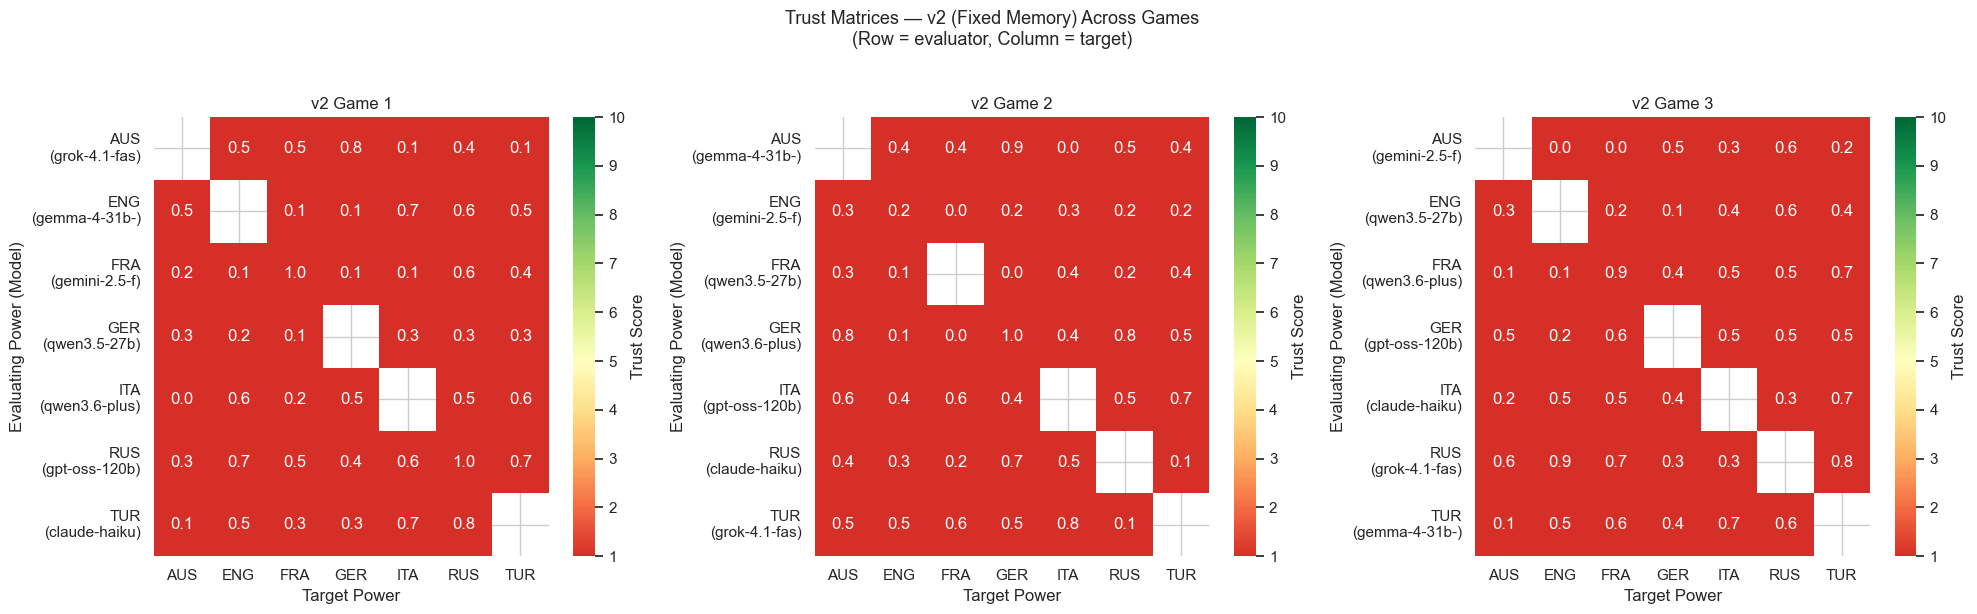

In [9]:
# Trust matrices for v2 games showing how alliances shift with power rotation
v2_data = trust_df[trust_df['experiment'] == 'v2']
powers = ['AUSTRIA', 'ENGLAND', 'FRANCE', 'GERMANY', 'ITALY', 'RUSSIA', 'TURKEY']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for game_num, ax in zip([1, 2, 3], axes):
    game_data = v2_data[v2_data['game'] == game_num]
    
    # Build trust matrix
    matrix = pd.DataFrame(np.nan, index=powers, columns=powers)
    for (eval_p, tgt_p), group in game_data.groupby(['evaluating_power', 'target_power']):
        if eval_p in powers and tgt_p in powers:
            matrix.loc[eval_p, tgt_p] = group['score'].mean()
    
    # Get model labels for this game
    v2_summary = load_experiment_summary(V2_DIR)
    pmap = v2_summary['results'][f'game{game_num}']['power_model_map']
    labels = [f"{p[:3]}\n({strip_model_prefix(pmap[p]).split('/')[-1][:12]})" for p in powers]
    
    sns.heatmap(matrix.astype(float), ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=1, center=0.5,
                xticklabels=[p[:3] for p in powers],
                yticklabels=labels,
                cbar_kws={'label': 'Trust Score'})
    ax.set_title(f'v2 Game {game_num}', fontsize=12)
    ax.set_xlabel('Target Power')
    ax.set_ylabel('Evaluating Power (Model)')

plt.suptitle('Trust Matrices — v2 (Fixed Memory) Across Games\n(Row = evaluator, Column = target)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

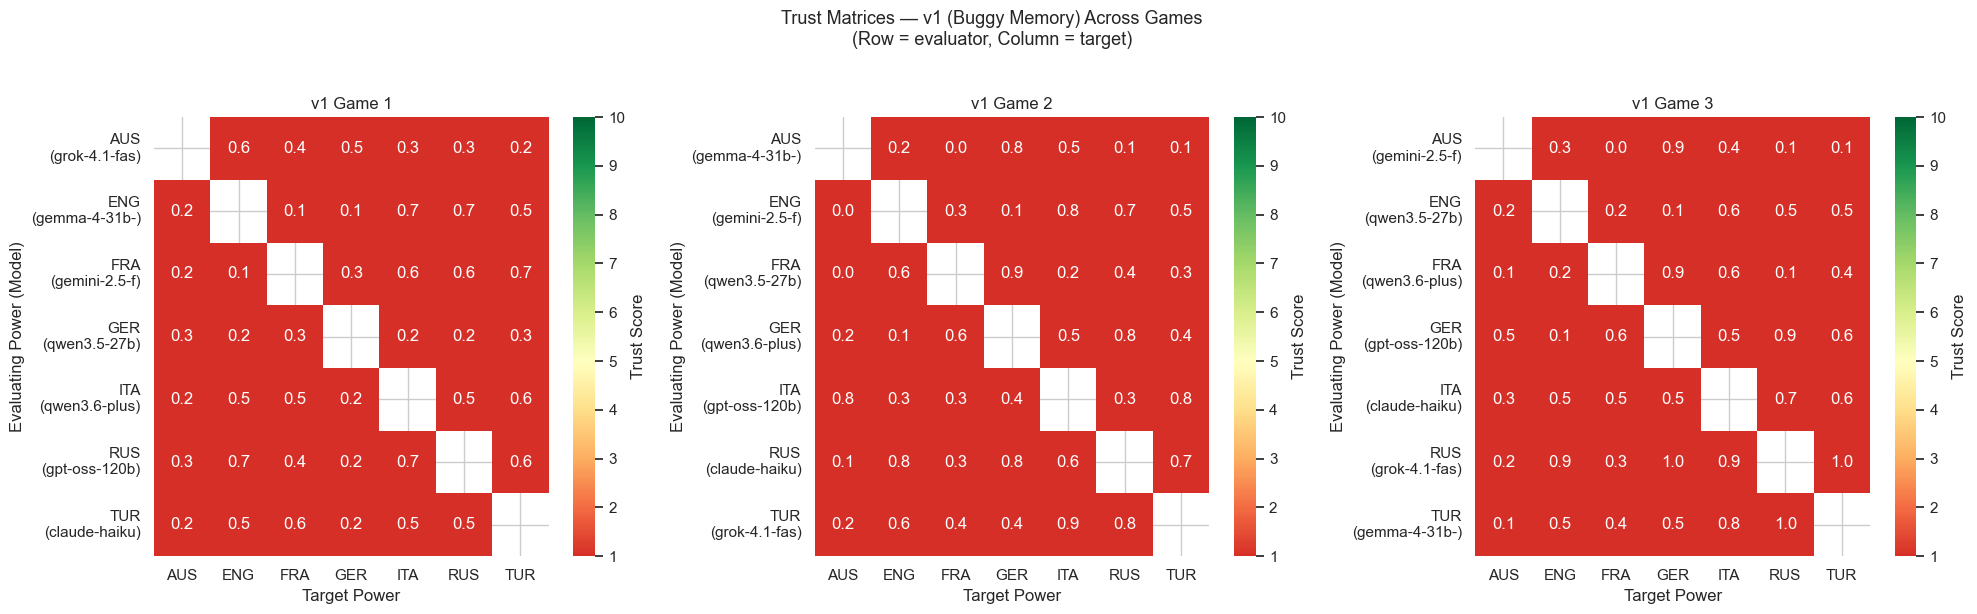

In [10]:
# Same for v1 for comparison
v1_data = trust_df[trust_df['experiment'] == 'v1']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for game_num, ax in zip([1, 2, 3], axes):
    game_data = v1_data[v1_data['game'] == game_num]
    
    matrix = pd.DataFrame(np.nan, index=powers, columns=powers)
    for (eval_p, tgt_p), group in game_data.groupby(['evaluating_power', 'target_power']):
        if eval_p in powers and tgt_p in powers:
            matrix.loc[eval_p, tgt_p] = group['score'].mean()
    
    v1_summary = load_experiment_summary(V1_DIR)
    pmap = v1_summary['results'][f'game{game_num}']['power_model_map']
    labels = [f"{p[:3]}\n({strip_model_prefix(pmap[p]).split('/')[-1][:12]})" for p in powers]
    
    sns.heatmap(matrix.astype(float), ax=ax, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=1, center=0.5,
                xticklabels=[p[:3] for p in powers],
                yticklabels=labels,
                cbar_kws={'label': 'Trust Score'})
    ax.set_title(f'v1 Game {game_num}', fontsize=12)
    ax.set_xlabel('Target Power')
    ax.set_ylabel('Evaluating Power (Model)')

plt.suptitle('Trust Matrices — v1 (Buggy Memory) Across Games\n(Row = evaluator, Column = target)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Trust Asymmetry / Sucker's Metric

In [11]:
def compute_asymmetries(df, experiment_label):
    """Compute trust asymmetries: A trusts B much more than B trusts A.
    
    The 'sucker' is the one giving high trust but receiving low trust back.
    """
    # Average trust per directed pair across all phases
    pair_trust = df.groupby(['evaluating_power', 'target_power', 'game'])['score'].mean().reset_index()
    
    asymmetries = []
    for game in pair_trust['game'].unique():
        game_data = pair_trust[pair_trust['game'] == game]
        for _, row_a in game_data.iterrows():
            p_a = row_a['evaluating_power']
            p_b = row_a['target_power']
            trust_a_to_b = row_a['score']
            
            # Find reverse
            reverse = game_data[(game_data['evaluating_power'] == p_b) & 
                               (game_data['target_power'] == p_a)]
            if not reverse.empty:
                trust_b_to_a = reverse['score'].values[0]
                asymmetry = trust_a_to_b - trust_b_to_a
                if asymmetry > 0:  # A is the 'sucker' - trusts B more than B trusts A
                    asymmetries.append({
                        'experiment': experiment_label,
                        'game': game,
                        'sucker': p_a,
                        'exploiter': p_b,
                        'trust_given': trust_a_to_b,
                        'trust_received': trust_b_to_a,
                        'asymmetry': asymmetry
                    })
    
    return pd.DataFrame(asymmetries)

v1_asym = compute_asymmetries(trust_df[trust_df['experiment'] == 'v1'], 'v1')
v2_asym = compute_asymmetries(trust_df[trust_df['experiment'] == 'v2'], 'v2')

print("TOP 10 TRUST ASYMMETRIES — v2 (Fixed Memory)")
print("="*70)
print("(Sucker gives high trust but receives low trust back)")
print()
if not v2_asym.empty:
    top_v2 = v2_asym.nlargest(10, 'asymmetry')[['game', 'sucker', 'exploiter', 'trust_given', 'trust_received', 'asymmetry']]
    display(top_v2.round(2))

print("\n\nTOP 10 TRUST ASYMMETRIES — v1 (Buggy Memory)")
print("="*70)
if not v1_asym.empty:
    top_v1 = v1_asym.nlargest(10, 'asymmetry')[['game', 'sucker', 'exploiter', 'trust_given', 'trust_received', 'asymmetry']]
    display(top_v1.round(2))

TOP 10 TRUST ASYMMETRIES — v2 (Fixed Memory)
(Sucker gives high trust but receives low trust back)



,game,sucker,exploiter,trust_given,trust_received,asymmetry
9,2,ITALY,AUSTRIA,0.64,0.05,0.60
22,1,AUSTRIA,GERMANY,0.82,0.29,0.53
21,1,AUSTRIA,FRANCE,0.52,0.16,0.36
56,3,RUSSIA,ENGLAND,0.89,0.56,0.33
16,2,TURKEY,ENGLAND,0.49,0.21,0.28
43,3,ENGLAND,AUSTRIA,0.27,0.02,0.25
57,3,RUSSIA,FRANCE,0.70,0.47,0.23
59,3,RUSSIA,TURKEY,0.81,0.59,0.22
52,3,GERMANY,RUSSIA,0.51,0.30,0.22
17,2,TURKEY,FRANCE,0.64,0.44,0.20




TOP 10 TRUST ASYMMETRIES — v1 (Buggy Memory)


,game,sucker,exploiter,trust_given,trust_received,asymmetry
22,2,AUSTRIA,GERMANY,0.85,0.24,0.61
24,2,ENGLAND,ITALY,0.80,0.33,0.47
55,3,RUSSIA,ENGLAND,0.92,0.51,0.41
0,1,AUSTRIA,ENGLAND,0.62,0.25,0.37
42,3,AUSTRIA,GERMANY,0.90,0.54,0.37
31,2,ITALY,AUSTRIA,0.83,0.49,0.34
26,2,FRANCE,GERMANY,0.88,0.55,0.33
35,2,RUSSIA,ITALY,0.58,0.25,0.32
50,3,FRANCE,GERMANY,0.90,0.61,0.29
25,2,FRANCE,ENGLAND,0.59,0.30,0.29


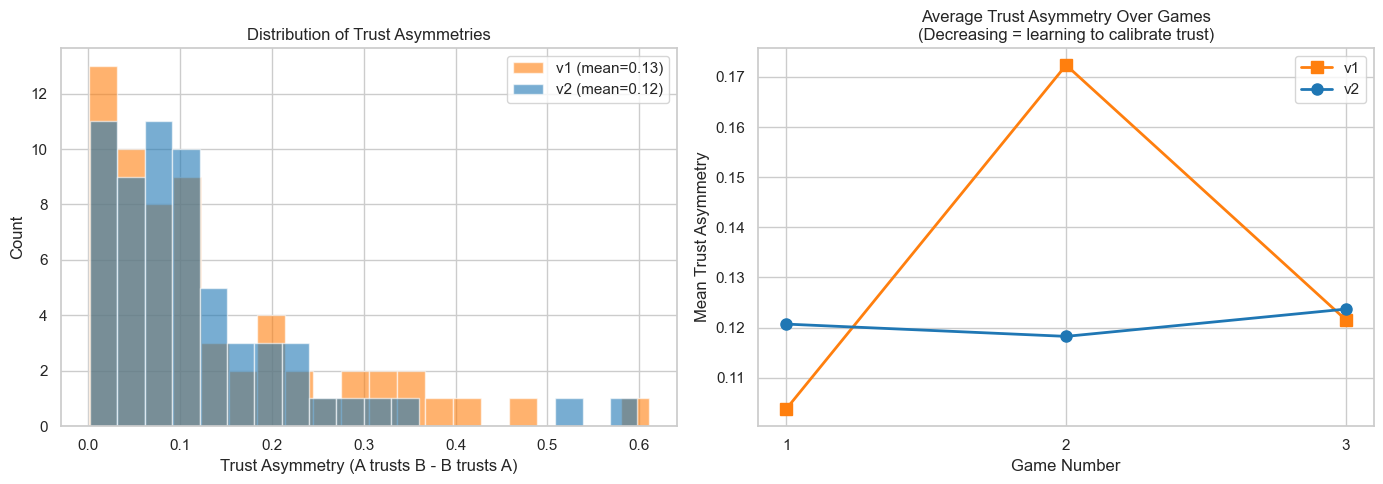

In [12]:
# Compare overall asymmetry distributions
all_asym = pd.concat([v1_asym, v2_asym], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of asymmetries
ax = axes[0]
for exp, color in [('v1', '#ff7f0e'), ('v2', '#1f77b4')]:
    data = all_asym[all_asym['experiment'] == exp]['asymmetry']
    if not data.empty:
        ax.hist(data, bins=20, alpha=0.6, color=color, label=f'{exp} (mean={data.mean():.2f})')
ax.set_xlabel('Trust Asymmetry (A trusts B - B trusts A)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Trust Asymmetries')
ax.legend()

# Average asymmetry by game
ax = axes[1]
asym_by_game = all_asym.groupby(['experiment', 'game'])['asymmetry'].mean().reset_index()
for exp, color, marker in [('v1', '#ff7f0e', 's'), ('v2', '#1f77b4', 'o')]:
    data = asym_by_game[asym_by_game['experiment'] == exp]
    ax.plot(data['game'], data['asymmetry'], color=color, marker=marker, 
            linewidth=2, markersize=8, label=exp)
ax.set_xlabel('Game Number')
ax.set_ylabel('Mean Trust Asymmetry')
ax.set_title('Average Trust Asymmetry Over Games\n(Decreasing = learning to calibrate trust)')
ax.set_xticks([1, 2, 3])
ax.legend()

plt.tight_layout()
plt.show()

## 7. Trust vs Game Success

In [13]:
# Load supply center counts for final game state
def get_sc_counts(exp_dir):
    """Get final supply center counts per power per game."""
    summary = load_experiment_summary(exp_dir)
    records = []
    for game_num in range(1, 4):
        game_key = f"game{game_num}"
        game_data = summary['results'][game_key]
        pmap = game_data['power_model_map']
        for power, sc_info in game_data['supply_centers'].items():
            records.append({
                'game': game_num,
                'power': power,
                'sc_count': sc_info['count'],
                'model': strip_model_prefix(pmap.get(power, 'unknown'))
            })
    return pd.DataFrame(records)

v1_sc = get_sc_counts(V1_DIR)
v1_sc['experiment'] = 'v1'
v2_sc = get_sc_counts(V2_DIR)
v2_sc['experiment'] = 'v2'
all_sc = pd.concat([v1_sc, v2_sc], ignore_index=True)

# Average RECEIVED trust per power per game
received_trust = trust_df.groupby(['experiment', 'game', 'target_power'])['score'].mean().reset_index()
received_trust.columns = ['experiment', 'game', 'power', 'avg_received_trust']

# Merge
trust_vs_sc = all_sc.merge(received_trust, on=['experiment', 'game', 'power'], how='inner')

print(f"Trust vs SC data: {len(trust_vs_sc)} rows")
trust_vs_sc.head()

Trust vs SC data: 42 rows


,game,power,sc_count,model,experiment,avg_received_trust
0,1,AUSTRIA,16,x-ai/grok-4.1-fast,v1,0.241129
1,1,ENGLAND,7,google/gemma-4-31b-it,v1,0.435081
2,1,FRANCE,7,google/gemini-2.5-flash-lite,v1,0.396371
3,1,GERMANY,3,qwen/qwen3.5-27b,v1,0.273413
4,1,ITALY,0,qwen/qwen3.6-plus,v1,0.490323


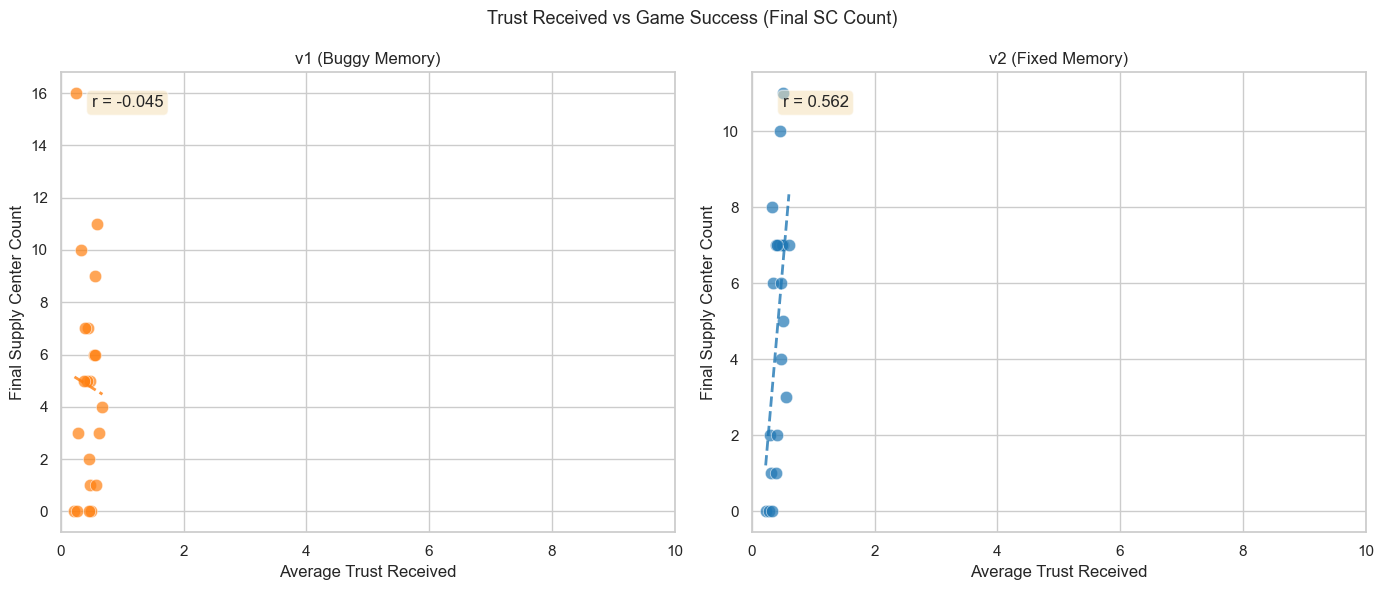


Correlation: Avg Received Trust vs Final SC Count
  v1: r = -0.045 (n=21)
  v2: r = 0.562 (n=21)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (exp, title, color) in enumerate([('v1', 'v1 (Buggy Memory)', '#ff7f0e'), 
                                          ('v2', 'v2 (Fixed Memory)', '#1f77b4')]):
    ax = axes[i]
    data = trust_vs_sc[trust_vs_sc['experiment'] == exp]
    
    ax.scatter(data['avg_received_trust'], data['sc_count'], 
              c=color, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
    
    # Add correlation line
    if len(data) > 2:
        z = np.polyfit(data['avg_received_trust'], data['sc_count'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['avg_received_trust'].min(), data['avg_received_trust'].max(), 100)
        ax.plot(x_line, p(x_line), color=color, linestyle='--', alpha=0.8, linewidth=2)
        
        # Correlation coefficient
        corr = data['avg_received_trust'].corr(data['sc_count'])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Average Trust Received')
    ax.set_ylabel('Final Supply Center Count')
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.suptitle('Trust Received vs Game Success (Final SC Count)', fontsize=13)
plt.tight_layout()
plt.show()

# Print correlations
print("\nCorrelation: Avg Received Trust vs Final SC Count")
print("="*50)
for exp in ['v1', 'v2']:
    data = trust_vs_sc[trust_vs_sc['experiment'] == exp]
    corr = data['avg_received_trust'].corr(data['sc_count'])
    print(f"  {exp}: r = {corr:.3f} (n={len(data)})")

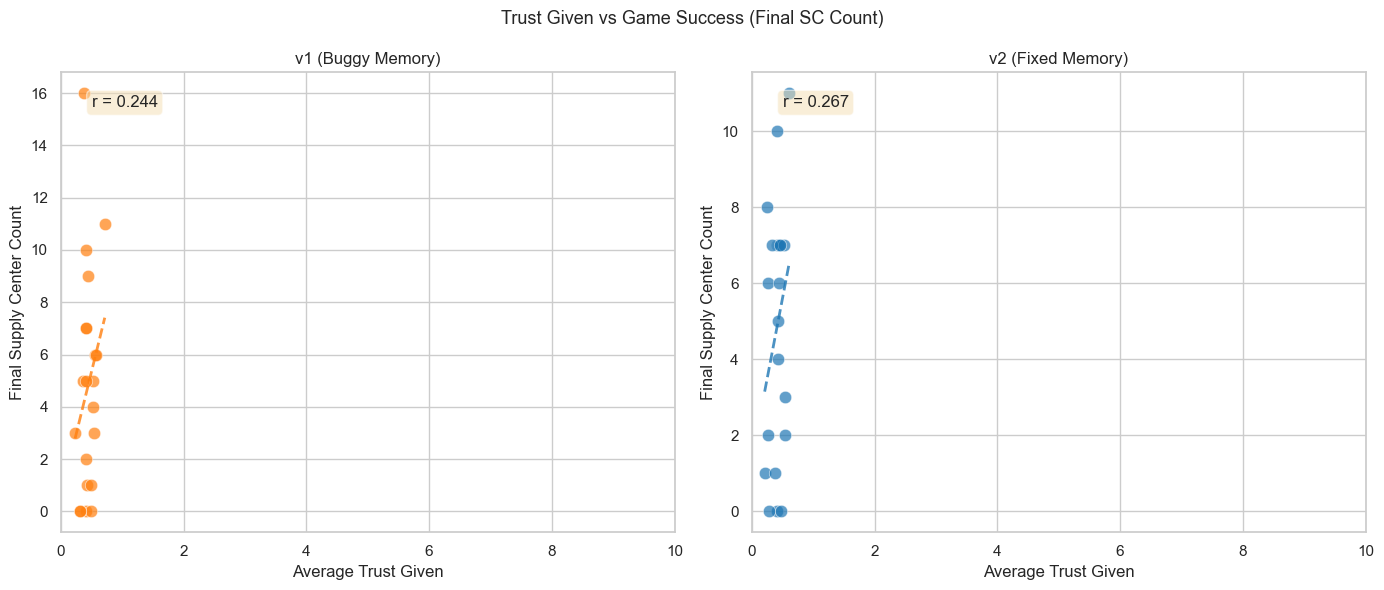

In [15]:
# Also look at trust GIVEN vs success (do trusting models do better or worse?)
given_trust = trust_df.groupby(['experiment', 'game', 'evaluating_power'])['score'].mean().reset_index()
given_trust.columns = ['experiment', 'game', 'power', 'avg_given_trust']

trust_given_vs_sc = all_sc.merge(given_trust, on=['experiment', 'game', 'power'], how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (exp, title, color) in enumerate([('v1', 'v1 (Buggy Memory)', '#ff7f0e'), 
                                          ('v2', 'v2 (Fixed Memory)', '#1f77b4')]):
    ax = axes[i]
    data = trust_given_vs_sc[trust_given_vs_sc['experiment'] == exp]
    
    ax.scatter(data['avg_given_trust'], data['sc_count'], 
              c=color, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)
    
    if len(data) > 2:
        z = np.polyfit(data['avg_given_trust'], data['sc_count'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['avg_given_trust'].min(), data['avg_given_trust'].max(), 100)
        ax.plot(x_line, p(x_line), color=color, linestyle='--', alpha=0.8, linewidth=2)
        
        corr = data['avg_given_trust'].corr(data['sc_count'])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
               fontsize=12, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Average Trust Given')
    ax.set_ylabel('Final Supply Center Count')
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.suptitle('Trust Given vs Game Success (Final SC Count)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Conclusions

### Summary of Findings

**Context**: We compare trust dynamics between two 3-game Diplomacy experiments using the same 7 LLMs:
- **v1**: Memory bug — models received another power's memory (power-keyed), so cross-game memory was effectively random/wrong
- **v2**: Memory fix — models receive their own memory (model-keyed), enabling genuine cross-game learning

**Key Questions Addressed**:

1. **Does correct memory change baseline trust levels?**
   - Compare the grouped bar charts in Section 2. If v2 models show systematically different trust levels, memory is influencing their default disposition.

2. **Does trust evolve differently over time with correct memory?**
   - Section 3 shows temporal progression. With correct memory (v2), we expect models to show more adaptive trust — decreasing trust toward betrayers, increasing toward reliable allies.

3. **Is there a stronger memory effect in games 2-3?**
   - Section 4 isolates games where memory should matter. Higher variance across games in v2 suggests models are genuinely adapting based on experience.

4. **Do alliance patterns shift with power rotation?**
   - Section 5 heatmaps show whether models trust based on power identity (geographic neighbors) vs model identity (past experience). In v2, trust should follow the model, not the power seat.

5. **Does correct memory reduce exploitation?**
   - Section 6: If memory works, trust asymmetry should decrease in later games as models learn to distrust exploiters.

6. **Does being trusted help you win?**
   - Section 7: The correlation between received trust and SC count shows whether diplomatic reputation translates to game success.